# Toda Oszillator

In [25]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

## Kapazität der Diode
Die Resonanzfrequenz im Serienschwingkreis ist $\omega_0=1/\sqrt{LC}$. Wenn wir also die Resonanzfrequenz messen, können wir die Kapazität bestimmen.

In [ ]:
# Messwertetabelle (aus dem eLab) 
reso_freq = {
    # Uoff in V : f in Hz
    -0.70 : 73.1e3,
    -0.63 : 72.3e3,
    -0.56 : 71.6e3,
    -0.49 : 70.7e3,
    -0.42 : 69.7e3,
    -0.35 : 68.8e3,
    -0.28 : 67.6e3,
    -0.21 : 66.5e3,
    -0.14 : 65.1e3,
    -0.07 : 63.6e3,
     0.00 : 61.8e3,
     0.03 : 61.0e3,
     0.06 : 60.0e3,
     0.09 : 59.0e3,
     0.12 : 57.9e3,
     0.15 : 56.5e3,
     0.18 : 54.8e3,
     0.21 : 52.4e3,
     0.24 : 48.2e3,
     0.27 : 40.1e3,
     0.30 : 24.9e3
}


C0 = 100e-12 # 100 pF

def Kapazität(Frequenz: np.ndarray) -> np.ndarray:
    L = 64e-3 # 64 mH
    C = []
    for freq in Frequenz:
        C.append(1/(L*freq*freq*4*np.pi*np.pi)) # 2 pi f = w
    return np.array(C) # Kapazität in F

[  23.9657247  -313.31849748   74.28190107] 2.114323440728471e-05


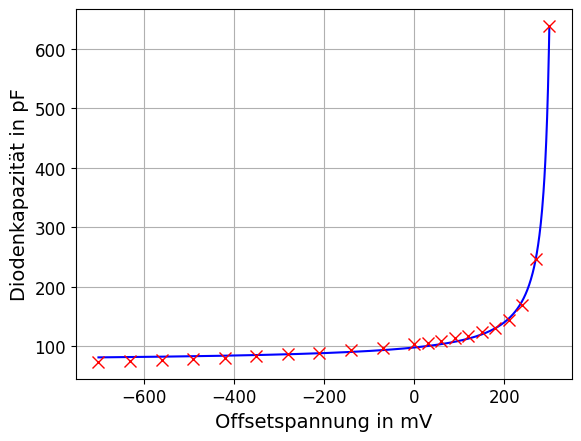

In [82]:
# Messwertelisten
Spannung = np.array(list(reso_freq))*1e3
Frequenz = np.array(list(reso_freq.values()))
Kapa = Kapazität(Frequenz)*1e12

# Fitten
def residuen_skript(coeff, U, C):
    c0, Us, o = coeff
    return C - (c0*Us)/(Us + U) - o

guess_skript = [100, -500, 50]

fit_skript = least_squares(residuen_skript, guess_skript, args=(Spannung, Kapa), method='lm')

Parameter_skript = fit_skript.x

print(Parameter_skript, fit_skript.optimality)
c0, Us, o = Parameter_skript

kontinuierlich = np.arange(min(Spannung), max(Spannung)+1)
modell_skript = (c0*Us)/(Us + kontinuierlich) + o

# plotting
fig, ax = plt.subplots()
ax.plot(kontinuierlich, modell_skript, "b", label="Modell")
ax.plot(Spannung, Kapa, "xr", label="Messwerte", ms=9)
ax.tick_params(axis="both", labelsize=12)
ax.set_xlabel("Offsetspannung in mV", fontsize=14)
ax.set_ylabel("Diodenkapazität in pF", fontsize=14)
ax.grid()
plt.show()